In [1]:
import torch
import datasets
import numpy as np
from datasets import Dataset
import statsmodels.api as sm
import matplotlib.pyplot as plt
from datasets import load_dataset
from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer

In [2]:
ls ../data/processed/

chunks.parquet


In [43]:
paragraphs = load_dataset("parquet", data_files="../data/interim/paragraphs.parquet", streaming=False)

Generating train split: 0 examples [00:00, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

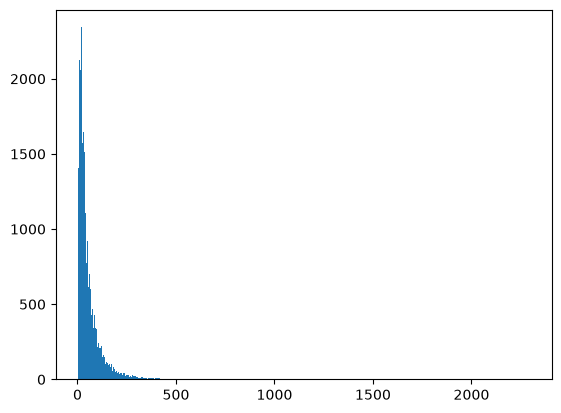

In [48]:
plt.hist(n_words_paragraphs[::1000], bins=500)
plt.show()

In [75]:
sorted_n_words_paragraphs = sorted(n_words_paragraphs)

In [76]:
sorted_n_words_paragraphs[-100:]

[np.int64(6377),
 np.int64(6386),
 np.int64(6427),
 np.int64(6447),
 np.int64(6453),
 np.int64(6462),
 np.int64(6519),
 np.int64(6572),
 np.int64(6581),
 np.int64(6775),
 np.int64(6794),
 np.int64(6852),
 np.int64(6873),
 np.int64(6876),
 np.int64(7091),
 np.int64(7136),
 np.int64(7247),
 np.int64(7286),
 np.int64(7296),
 np.int64(7296),
 np.int64(7296),
 np.int64(7297),
 np.int64(7306),
 np.int64(7306),
 np.int64(7306),
 np.int64(7306),
 np.int64(7337),
 np.int64(7394),
 np.int64(7475),
 np.int64(7475),
 np.int64(7563),
 np.int64(7647),
 np.int64(7755),
 np.int64(7797),
 np.int64(7797),
 np.int64(7797),
 np.int64(7797),
 np.int64(7833),
 np.int64(7855),
 np.int64(7874),
 np.int64(7880),
 np.int64(7905),
 np.int64(7926),
 np.int64(8030),
 np.int64(8124),
 np.int64(8258),
 np.int64(8258),
 np.int64(8258),
 np.int64(8258),
 np.int64(8594),
 np.int64(8725),
 np.int64(8776),
 np.int64(9037),
 np.int64(9037),
 np.int64(9037),
 np.int64(9037),
 np.int64(9050),
 np.int64(9079),
 np.int64(9130

In [3]:
chunks = load_dataset("parquet", data_files="../data/processed/chunks.parquet", streaming=False)

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [46]:
n_words_paragraphs = [n for n in paragraphs["train"]["n_words"]]
n_words_paragraphs = np.array(n_words_paragraphs)

In [110]:
splitted_paragraphs = [n for n in chunks["train"]["splitted_paragraphs"]]
splitted_paragraphs = np.array(splitted_paragraphs)

In [115]:
np.where(splitted_paragraphs == True)

(array([     505,      506,      507, ..., 15509859, 15509860, 15509861],
       shape=(21511,)),)

In [114]:
n_words = [n for n in chunks["train"]["n_words"]]
n_words = np.array(n_words)

In [29]:
n_words = np.array(n_words)

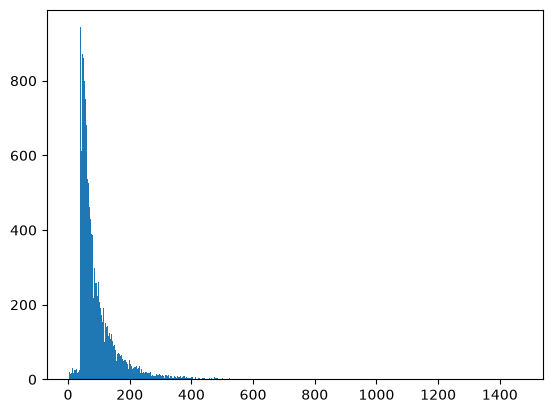

In [49]:
plt.hist(n_words[::1000], bins=500)
plt.show()

In [55]:
sorted_n_words = sorted(n_words)

In [57]:
sorted_n_words[-100:]

[np.int64(1490),
 np.int64(1490),
 np.int64(1490),
 np.int64(1490),
 np.int64(1491),
 np.int64(1492),
 np.int64(1492),
 np.int64(1492),
 np.int64(1492),
 np.int64(1493),
 np.int64(1493),
 np.int64(1493),
 np.int64(1493),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1494),
 np.int64(1495),
 np.int64(1495),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1496),
 np.int64(1497),
 np.int64(1497),
 np.int64(1497),
 np.int64(1498),
 np.int64(1498),
 np.int64(1498),
 np.int64(1499),
 np.int64(1499),
 np.int64(1499),
 np.int64(1499),
 np.int64(1500),
 np.int64(1500),
 np.int64(1500),
 np.int64(1511),
 np.int64(1520),
 np.int64(1537),
 np.int64(1550),
 np.int64(1550),
 np.int64(1556),
 np.int64(1594),
 np.int64(1598),
 np.int64(1599),
 np.int64(1620),
 np.int64(1675),
 np.int64(1676),
 np.int64(1698),
 np.int64(1724),
 np.int64(1779),
 np.int64(1782

Let's qq plot the two samples to compare them.

In [91]:
n = min(len(n_words), len(n_words_paragraphs))
q = np.linspace(0, 1, n)[::100]
q1 = np.quantile(sorted_n_words, q)
q2 = np.quantile(sorted_n_words_paragraphs, q)

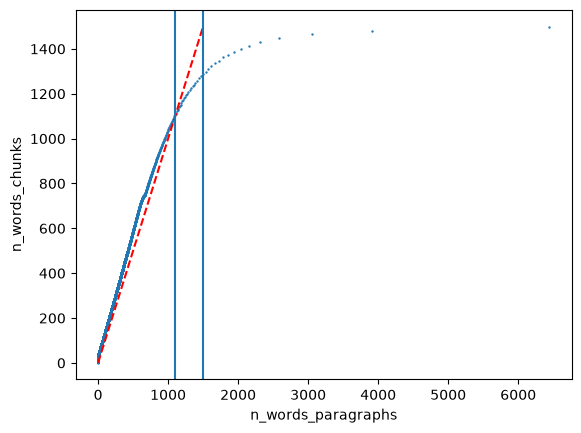

In [95]:
plt.scatter(q2, q1, s=0.5)
plt.plot([q1.min(), q1.max()], [q1.min(), q1.max()], 'r--')
plt.xlabel("n_words_paragraphs")
plt.ylabel("n_words_chunks")
plt.axvline(x=1500)
plt.axvline(x=1100)
plt.show()

In [105]:
np.where((n_words >= 1490) & (n_words <= 1500))

(array([  473060,   489195,   495823,   755817,   777842,   802384,
          992370,   993116,   993528,  1759638,  1900618,  2928059,
         3722464,  5056990,  5065569,  5079097,  5095404,  6948311,
         7156243,  7254503,  7429216,  7455899,  8508891,  9498049,
         9836440, 10066928, 10276137, 10396136, 10507985, 11316600,
        11316620, 11396678, 11727359, 12356648, 13045232, 13067415,
        13070089, 13316505, 13316686, 13316744, 13648388, 14132029,
        14287623, 14939519, 14962519]),)

In [101]:
def print_chunk_infos(chunk_id):
    """
    Takes the id of the chunk and print its content, number of words and test_id
    """
    print("N_words", chunks["train"]["n_words"][chunk_id])
    print("Text_id", chunks["train"]["text_ids"][chunk_id])
    print("Paragraph", chunks["train"]["paragraphs"][chunk_id])
    print("Splitted", chunks["train"]["splitted_paragraphs"][chunk_id])
    
    
    
    

In [102]:
np.where(n_words == 3114)

(array([5903516]),)

In [131]:
np.where(n_words==1)

(array([ 3793654,  7365523, 11203310]),)

In [3]:
#print_chunk_infos(7365524)

## Embedding

In [4]:
chunks = chunks.filter(lambda chunk: chunk["n_words"] >= 40)

In [5]:
chunks

DatasetDict({
    train: Dataset({
        features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs'],
        num_rows: 15259570
    })
})

In [6]:
n_words_chunks_filtered = [n for n in chunks["train"]["n_words"]]
n_words_chunks_filtered = np.array(n_words_chunks_filtered)

In [7]:
import torch
from sentence_transformers import SentenceTransformer

In [8]:
import torch

In [15]:
torch.mps.is_available()

True

In [ ]:
torch.mps.is_available()

In [16]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda:0"
elif torch.mps.is_available():
    device = "mps:0"

In [25]:
model_bf16_flash = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.bfloat16, "attn_implementation":"flash_attention_2"})



model_bf16 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.bfloat16})

model_float32 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device)

model_float32 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                    model_kwargs={"attn_implementation":"flash_attention_2"})

ImportError: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package flash_attn seems to be not installed. Please refer to the documentation of https://huggingface.co/docs/transformers/perf_infer_gpu_one#flashattention-2 to install Flash Attention 2.

In [ ]:
model_bf16 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.bfloat16})

In [ ]:
model_float32 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device)

In [ ]:
model_float32 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                    model_kwargs={"attn_implementation":"flash_attention_2"})

In [9]:
chunk_sorted = chunks.sort("n_words", reverse=True)

In [10]:
chunk_sorted["train"]["n_words"]

Column([17123, 13740, 12062, 7833, 7247, ...])

In [2]:
def encode_chunk(chunk, batch_size= 64, convert_to_numpy=True, normalize_embeddings=True):
    """
    Wrapper to the embedding function, for using with .map.
    """
    return {"embeddings":model.encode(chunk, batch_size= batch_size,convert_to_numpy=convert_to_numpy, normalize_embeddings=normalize_embeddings, num_proc=4)}
    
chunk_sorted = chunk_sorted.map(lambda chunk, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 2, "convert_to_numpy":True, "normalize_embeddings":True},
                    batch_size=2, batched=True)

NameError: name 'chunk_sorted' is not defined

In [17]:
chunk_sorted = chunk_sorted.map(lambda chunk, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 2, "convert_to_numpy":True, "normalize_embeddings":True},
                    batch_size=2, batched=True)

Map:   0%|          | 0/15259570 [00:00<?, ? examples/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 39.49 GiB of which 705.56 MiB is free. Including non-PyTorch memory, this process has 38.79 GiB memory in use. Of the allocated memory 37.86 GiB is allocated by PyTorch, and 445.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [ ]:
chunks = chunks.map(lambda chunk, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 1, "convert_to_numpy":True, "normalize_embeddings":True},
                    batch_size=64, batched=True)

In [10]:
import torch
print(torch.cuda.is_available())
print(model.device)

True
cuda:0


In [172]:
chunks["train"]["paragraphs"][0]

'Having, by a train of fortunate circumstances, accomplished a voyage, of which the history of mankind affords no example; having, moreover, exerted every faculty of body and mind, to make my adventures useful to my countrymen, and even to mankind, by imparting to them the acquisition of secrets in physics and morals, of which they had not formed the faintest conception,--I flattered myself that both in the character of traveller and public benefactor, I had earned for myself an immortal name. But how these fond, these justifiable hopes have been answered, the following narrative will show.'

In [11]:
model = model.eval()

In [208]:
test_ds = Dataset.from_dict(chunks["train"]["paragraphs"][0:1024])

AttributeError: 'list' object has no attribute 'items'

In [210]:
texts = chunks["train"].select(range(1024))["paragraphs"]

In [215]:
texts[1024]

IndexError: Invalid key: 1024 is out of bounds for size 1024

In [20]:
%%time
model = model.eval()
with torch.no_grad():
    model.max_seq_length = 2048
    sorted_chunks = sorted(chunks["train"]["paragraphs"][0:1000], key=len)
    embeddings = model.encode(sorted_chunks, device="cuda:0",  batch_size= 128,convert_to_numpy=True, normalize_embeddings=True, num_proc = 8)

CPU times: user 511 ms, sys: 18 ms, total: 529 ms
Wall time: 307 ms


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.38 GiB. GPU 0 has a total capacity of 39.49 GiB of which 263.56 MiB is free. Including non-PyTorch memory, this process has 39.23 GiB memory in use. Of the allocated memory 37.16 GiB is allocated by PyTorch, and 1.57 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [294]:
15000000/(2*4096)*7/60

213.623046875

In [228]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "BAAI/bge-small-en-v1.5",
    use_fast=True
)

In [238]:
tt = Dataset.from_dict({"text":chunks["train"]["paragraphs"][0:1000000]})

In [243]:
%time
tokenized_ds = chunks.map(lambda t:tokenizer(t['paragraphs']), batched=True)

CPU times: user 6 μs, sys: 2 μs, total: 8 μs
Wall time: 16.7 μs


Map:   0%|          | 0/15259570 [00:00<?, ? examples/s]

In [278]:
%%time
with torch.no_grad():
    outputs = model(
        d
    )


CPU times: user 419 μs, sys: 254 μs, total: 673 μs
Wall time: 680 μs


AttributeError: 'Column' object has no attribute 'size'

In [277]:
d = {'input_ids':tokenized_ds["train"]['input_ids'], 
 'token_type_ids':tokenized_ds["train"]['token_type_ids'], 
'attention_mask':tokenized_ds["train"]['attention_mask']}

In [276]:
tokenized_ds["train"]

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15259570
})

In [3]:
import torch
print(torch.cuda.is_available())
print(next(model.parameters()).device)

True


NameError: name 'model' is not defined

In [178]:
torch.backends.mps.is_available()

True

In [179]:
print(next(model.parameters()).device)

mps:0


In [192]:
model

SentenceTransformer(
  (0): Transformer({'max_seq_length': 32768, 'do_lower_case': False}) with Transformer model: Qwen3Model 
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': True, 'include_prompt': True})
  (2): Normalize()
)

In [29]:
echo HF_HOME

SyntaxError: invalid character '§' (U+00A7) (1648055872.py, line 1)

In [ ]:
model.max_seq_length = 128

In [297]:
np.percentile(n_words_chunks_filtered, 99.9)

np.float64(807.0)

In [26]:
ls

dataset_exploration.ipynb  embedding_exploration.ipynb  Untitled.ipynb


## Experimenting embedding speed

In [45]:
chunks = load_dataset("parquet", data_files="../data/processed/chunks.parquet", streaming=False)["train"]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [46]:
chunks = chunks.filter(lambda chunk: chunk["n_words"] >= 40)

In [4]:
chunks_subset = chunks.shuffle(seed=42, keep_in_memory=False).select(range(100000))

In [5]:
chunks_subset

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs'],
    num_rows: 100000
})

In [6]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda:0"
elif torch.mps.is_available():
    device = "mps:0"

In [7]:
print(device)

cuda:0


In [9]:
model_bf16_flash = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.bfloat16, "attn_implementation":"sdpa"})



model_bf16 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.bfloat16})

model_float32 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device)

model_float32_flash = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                    model_kwargs={"attn_implementation":"sdpa"})

In [16]:
model_bf16_flash_0 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device="cuda:0", 
                            model_kwargs={"dtype": torch.bfloat16, "attn_implementation":"sdpa"})

model_bf16_flash_1 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device="cuda:1", 
                            model_kwargs={"dtype": torch.bfloat16, "attn_implementation":"sdpa"})

model_bf16_flash_2 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device="cuda:2", 
                            model_kwargs={"dtype": torch.bfloat16, "attn_implementation":"sdpa"})

model_bf16_flash_3 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device="cuda:3", 
                            model_kwargs={"dtype": torch.bfloat16, "attn_implementation":"sdpa"})

In [10]:
pool_bf16_flash = model_bf16_flash.start_multi_process_pool()
pool_bf16 = model_bf16.start_multi_process_pool()
pool_float32 = model_float32.start_multi_process_pool()
pool_float32_flash = model_float32_flash.start_multi_process_pool()

In [11]:
chunk_subset_sorted = chunks_subset.sort("n_words", reverse=False)

In [2]:
def encode_chunk(chunk, model= None, batch_size= 64, convert_to_numpy=True, normalize_embeddings=True):
    """
    Wrapper to the embedding function, for using with .map.
    """
    return {"embeddings":model.encode(chunk, batch_size= batch_size,convert_to_numpy=convert_to_numpy, normalize_embeddings=normalize_embeddings, num_proc=4)}
    

In [43]:
chunk_subset_f32 = chunks_subset.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 8, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_float32},
                    batch_size=8, batched=True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [14]:
chunk_subset_f32_flash = chunks_subset.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 256, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_float32_flash},
                    batch_size=8, batched=True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [58]:
len(chunk_subset_f32_flash2['embeddings'][0])

1024

In [59]:
chunk_subset_bf16 = chunks_subset.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 8, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_bf16},
                    batch_size=8, batched=True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [60]:
chunk_sorted_subset_bf16 = chunk_subset_sorted.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 8, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_bf16},
                    batch_size=8, batched=True)

In [15]:
chunk_sorted_subset_bf16_flash = chunk_subset_sorted.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 8, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_bf16_flash},
                    batch_size=8, batched=True)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [1]:
chunks

NameError: name 'chunks' is not defined

In [31]:
chunk_subset_sorted_cut = chunk_subset_sorted.filter(lambda chunk: chunk["n_words"] <= 1500)

Filter:   0%|          | 0/100000 [00:00<?, ? examples/s]

In [44]:
chunk_sorted_subset_bf16_flash_0 = chunk_subset_sorted.select(range(3*100000//4, 100000)).map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 64, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_bf16_flash_0},
                    batch_size=64, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [38]:
chunk_subset_sorted["n_words"][-10:]

[1350, 1362, 1370, 1372, 1412, 1476, 1477, 1492, 1500, 3352]

In [23]:
chunk_subset_sorted.select(range(100000//4))

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs'],
    num_rows: 25000
})

In [29]:
list(range(10, 40))

[10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39]

## Evaluating the impact of quantization on the embedding structure

In [3]:
chunks = load_dataset("parquet", data_files="../data/processed/chunks.parquet", streaming=False)["train"]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

In [4]:
chunks = chunks.filter(lambda chunk: chunk["n_words"] >= 40)

In [5]:
chunks_subset = chunks.shuffle(seed=42, keep_in_memory=False).select(range(10000))

In [6]:
chunk_sorted = chunks_subset.sort("n_words", reverse=True)

In [7]:
chunk_sorted

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs'],
    num_rows: 10000
})

In [8]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda:0"
elif torch.mps.is_available():
    device = "mps:0"

In [9]:
model_bf16 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.bfloat16})



model_f32 = SentenceTransformer("IEITYuan/Yuan-embedding-2.0-en", device=device, 
                            model_kwargs={"dtype": torch.float32})

In [10]:
chunks_32 = chunk_sorted.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 8, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_f32},
                    batch_size=8, batched=True)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [11]:
chunks_16 = chunk_sorted.map(lambda chunk, model, batch_size, convert_to_numpy, 
                    normalize_embeddings: encode_chunk(chunk["paragraphs"], model, batch_size, convert_to_numpy, normalize_embeddings), 
                   fn_kwargs={"batch_size": 8, "convert_to_numpy":True, "normalize_embeddings":True, "model":model_bf16},
                    batch_size=8, batched=True)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [12]:
embeddings_32 = np.array(chunks_32["embeddings"])
embeddings_32_then_16 = np.array(chunks_32["embeddings"]).astype(np.float16)

In [13]:
embeddings_16 = np.array(chunks_16["embeddings"])
embeddings_16_then_16 = np.array(chunks_16["embeddings"]).astype(np.float16)
embeddings_16_then_32 = np.array(chunks_16["embeddings"]).astype(np.float32)

In [14]:
print(np.mean(embeddings_16_then_16 == embeddings_16))

0.9999916015625


In [15]:
print(np.mean(embeddings_32_then_16 == embeddings_32))

0.00012666015625


In [16]:
print(np.mean(embeddings_16_then_32 == embeddings_16))

1.0


This shows that even though the embeddings are stored in float32 format, in practice the bfloat16 model output bfloat16 embeddings

In [17]:
embeddings_32.shape

(10000, 1024)

In [18]:
embeddings_16_then_16.shape

(10000, 1024)

In [19]:
similarity_matrix_32 = embeddings_32@embeddings_32.T

In [20]:
similarity_matrix_16 = embeddings_16_then_16.astype(np.float32)@embeddings_16_then_16.astype(np.float32).T

In [21]:
np.fill_diagonal(similarity_matrix_16, -np.inf)
np.fill_diagonal(similarity_matrix_32, -np.inf)

In [56]:
k = 50
topk_16 = np.argsort(-similarity_matrix_16, axis=1)[:, :k]
topk_32 = np.argsort(-similarity_matrix_32, axis=1)[:, :k]

In [57]:
(topk_16 == topk_32).mean()

np.float64(0.250652)

Checking if the neighbors that change between float16 and float32 have lower dot products. It turns out
not really:

In [58]:
row_indexes_diff, col_indexes_diff = np.asarray(topk_16 != topk_32).nonzero()
row_indexes_eq, col_indexes_eq = np.asarray(topk_16 == topk_32).nonzero()

In [59]:
topk_16 == topk_32

array([[ True,  True,  True, ...,  True, False, False],
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ..., False,  True, False],
       [ True,  True,  True, ..., False, False, False]], shape=(10000, 50))

In [60]:
diff_dot_prod = np.array([similarity_matrix_32[r, topk_32[r, c]] for r,c in zip(row_indexes_diff, col_indexes_diff)])
eq_dot_prod = np.array([similarity_matrix_32[r, topk_32[r, c]] for r,c in zip(row_indexes_eq, col_indexes_eq)])

(array([5.91411424e-03, 9.29360810e-03, 1.77423427e-02, 2.02769631e-02,
        2.87256978e-02, 5.15372813e-02, 5.91411424e-02, 8.19527260e-02,
        1.57991338e-01, 2.45013304e-01, 3.96245654e-01, 5.50012625e-01,
        8.22906753e-01, 1.10678424e+00, 1.61117369e+00, 2.33692000e+00,
        3.44539398e+00, 4.59526677e+00, 6.28923806e+00, 8.11838911e+00,
        9.94585041e+00, 1.12968031e+01, 1.17817604e+01, 1.16406666e+01,
        9.86051819e+00, 7.87675530e+00, 5.51448910e+00, 3.60760969e+00,
        2.25243265e+00, 1.17099462e+00, 5.24666421e-01, 2.86412104e-01,
        1.11523297e-01, 3.54846855e-02, 1.52077223e-02, 8.44873464e-03,
        0.00000000e+00, 1.68974693e-03, 1.68974693e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.68974693e-03]),
 array([0.5238351 , 0.53327935, 0.54272359, 0.55216783, 0.56161208,
        0.57105632, 0.5805

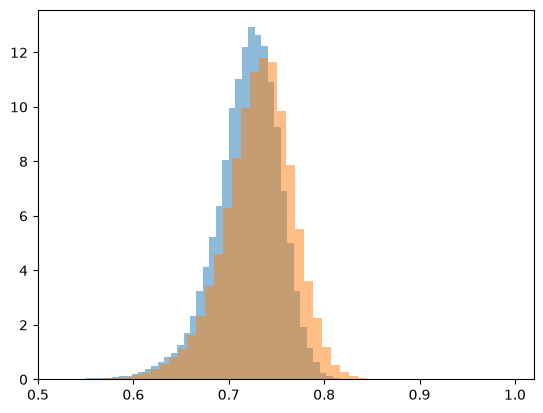

In [61]:
plt.hist(diff_dot_prod, alpha=0.5, density=True, bins=50)
plt.hist(eq_dot_prod, alpha=0.5, density=True, bins=50)

In [86]:
rows_n_cols_diff[rows_n_cols_diff[:, 0] ==0]

array([[ 0, 10],
       [ 0, 11],
       [ 0, 14],
       [ 0, 15],
       [ 0, 16],
       [ 0, 17],
       [ 0, 18],
       [ 0, 19],
       [ 0, 20],
       [ 0, 22],
       [ 0, 24],
       [ 0, 25],
       [ 0, 26],
       [ 0, 28],
       [ 0, 29],
       [ 0, 30],
       [ 0, 32],
       [ 0, 33],
       [ 0, 34],
       [ 0, 35],
       [ 0, 39],
       [ 0, 40],
       [ 0, 41],
       [ 0, 42],
       [ 0, 44],
       [ 0, 46],
       [ 0, 48],
       [ 0, 49]])

Now looking at the margins between neighbors:

In [120]:
rows_n_cols_diff = np.array(list(zip(row_indexes_diff, col_indexes_diff)))
all_float32 = []
all_float16 = []
all_diffs_diff = []
for i in tqdm(range(10000)):
    rows_n_cols_i = rows_n_cols_diff[rows_n_cols_diff[:, 0] ==i]
    dot_prod_i_float32 = np.array([similarity_matrix_32[l, topk_32[l, m]] for l, m in rows_n_cols_i])
    dot_prod_i_float16 = np.array([similarity_matrix_32[l, topk_16[l, m]] for l, m in rows_n_cols_i])
    all_float32.append(dot_prod_i_float32)
    all_float16.append(dot_prod_i_float16)
    all_diffs_diff.append(dot_prod_i_float32 - dot_prod_i_float16)

    
    

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:12<00:00, 785.78it/s]


In [121]:
all_diffs_diff = np.concat(all_diffs_diff)
all_float32  = np.concat(all_float32)
all_float16 = np.concat(all_float16) 

In [108]:
np.mean(np.abs(all_diffs_diff))

np.float64(0.0011145664944386515)

In [109]:
np.median(np.abs(all_diffs_diff))

np.float64(0.0009291539518654912)

In [114]:
len(dot_prod_i_float32)

36

In [124]:
from scipy.stats import ks_2samp
statistic, pvalue = ks_2samp(all_float32, all_float16)
print(pvalue)

0.9419224615888269


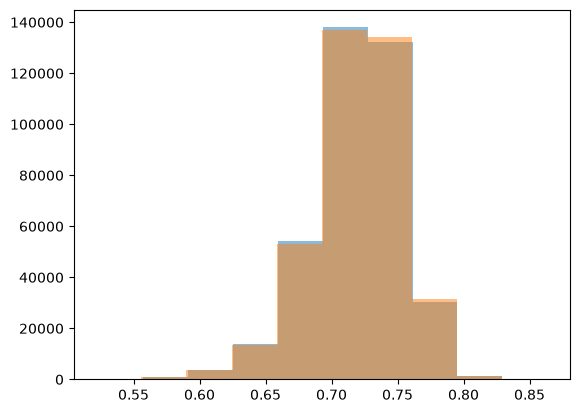

In [122]:
plt.hist(all_float32, alpha=0.5)
plt.hist(all_float16, alpha=0.5)
plt.show()

In [ ]:
diff_dot_prod = np.array([similarity_matrix_32[r, topk_32[r, c]] for r,c in zip(row_indexes_diff, col_indexes_diff)])

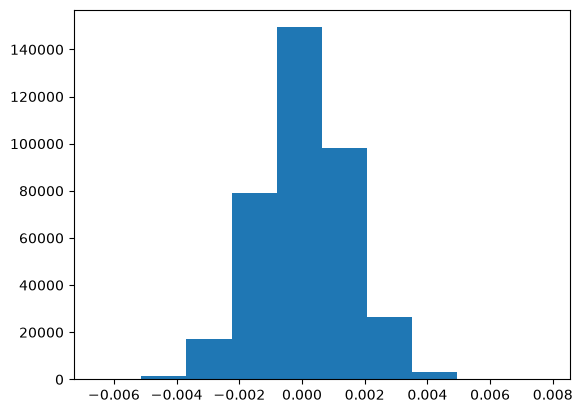

In [106]:
plt.hist(all_diffs_diff.flatten())
plt.show()

In [ ]:
rows_n_cols_eq = np.array(list(zip(row_indexes_diff, col_indexes_diff)))
all_diffs_diff = []
for i in tqdm(range(10000)):
    rows_n_cols_i = rows_n_cols_diff[rows_n_cols_diff[:, 0] ==i]
    dot_prod_i = np.array([similarity_matrix_32[l, m] for l, m in rows_n_cols_i])
    all_diffs_diff.append(dot_prod_i[:-1] - dot_prod_i[1:])

In [67]:
from tqdm import tqdm
all_diffs_diff = []
for r in tqdm(row_indexes_diff[:1000]):
    sim = np.array([similarity_matrix_32[r, topk_32[r, c]] for c in col_indexes_diff])
    all_diffs_diff.append(sim[:-1] - sim[1:])

374674

In [62]:
diff_dot_prod = np.array([[similarity_matrix_32[r, topk_32[r, c]] for c in col_indexes_diff] for r in tqdm(row_indexes_diff]))
eq_dot_prod = np.array([[similarity_matrix_32[r, topk_32[r, c]] for c in col_indexes_eq] for r in row_indexes_eq])

KeyboardInterrupt: 

In [63]:
[1, 2] - [2, 3]

TypeError: unsupported operand type(s) for -: 'list' and 'list'

In [24]:
topk_16

array([[ 458,  590, 7970, 5341, 1243],
       [1311,  960,    8, 7058,  272],
       [2881, 4332,  637,  319,  811],
       ...,
       [ 657, 3257, 4732, 5796, 7193],
       [7267, 2148,  808, 2191, 2797],
       [5647, 5762, 9485, 4058, 4915]], shape=(10000, 5))

In [136]:
np.argmax(similarity_matrix_32)

np.int64(52735311)

In [137]:
row, col = np.unravel_index(np.argmax(similarity_matrix_32), similarity_matrix_32.shape)

In [138]:
row

np.int64(5273)

In [139]:
col

np.int64(5311)

In [140]:
chunks_32[-1]["paragraphs"]

'"I am not afraid to be answerable for this," responded Taras, "for the Right is more to be valued than any man\'s life. Both my conscience and my reason tell me that, for the world itself is founded on justice."'

In [141]:
np.argmax(similarity_matrix_32[-1])

np.int64(5647)

In [111]:
chunks_32[5647]["paragraphs"]

'"This man," he cried at last, above the persisting clamor--"this man is guilty; he should die!" The uproar broke out afresh. "He has put human beings to death without authority from the people. He _must_ die!"\n\n"But, citoyens," Barabant burst out, "neither have we the right of death. Denounce him, arrest him, but obey the law. Respect the law; respect justice. Citoyens, I demand the arrestation."'

In [73]:
chunks_32[780]["paragraphs"]

"DOANE left the compound a little before noon, and arrived at So T'ung at six the following morning. The distance, a hundred and eighty _li_, was just short of sixty-five English miles. The road was little more than a footpath, so narrow that in the mountains, where the grinding of ages of traffic and the drainage from eroded slopes had long ago worn it down into a series of deep, narrow canyons, the came! trains, with their wide panniers, always found passing a matter of difficulty and confusion. Here it skirted a precipice, or twisted up and up to surmount the Pass of the Flighting Geese, just west of the sacred mountain; there it wandered along the lower hillsides above a spring torrent that would be, a few months later, a trickling rivulet. His gait averaged, over all conditions of road and of gradient, about five miles an hour. He followed, on this occasion, the principle of walking an hour, then resting fifteen minutes. And toward midnight he set up his cot by the roadside, in th

In [74]:
chunks_32[638]["paragraphs"]

"A very pleasant half hour was spent at this place, enjoying their hospitality, and then we pushed on. We were now going westward up the valley, which held a straight course of about six miles, and then turned around to the north. The trail being good, we walked very rapidly till nightfall in a supreme effort to reach our camp that night. Having now been on our feet almost continuously for the past fifteen hours, we had become so fatigued that a very slight obstruction was sufficient to cause a fall, and every few minutes some one of the party would go headlong among the burnt timber. We had barely enough provisions for another meal, however, and so we desired to get as near headquarters as possible. At length, nightfall having rendered farther progress impossible, we found a fairly level place among the prostrate trees, and, after a meal of bacon and hard tack, lay down on the ground around a large fire. The night was mild, and extreme weariness gave us sound sleep. After four hours o

In [75]:
similarity_matrix_32[780][638]

np.float64(0.7420297453126541)

In [66]:
chunks_32[32]["text_ids"]

'52258'

In [68]:
chunks_32[49]["text_ids"]

'32257'

In [60]:
chunks_32

Dataset({
    features: ['paragraphs', 'text_ids', 'spans', 'chapters', 'n_words', 'splitted_paragraphs', 'embeddings'],
    num_rows: 10000
})

In [78]:
moby_dick1 = """"Landlord," said I, going up to him as cool as Mt. Hecla in a snowstorm—"landlord, stop whittling. You and I must understand one another, 
and that too without delay. I come to your house and want a bed; you tell me you can only give me half a one; 
that the other half belongs to a certain harpooneer. And about this harpooneer, whom I have not yet seen, 
you persist in telling me the most mystifying and exasperating stories tending to beget in me an uncomfortable feeling towards 
the man whom you design for my bedfellow—a sort of connexion, landlord, which is an intimate and confidential one in the highest degree. 
I now demand of you to speak out and tell me who and what this harpooneer is, and whether I shall be in all respects safe to 
spend the night with him. And in the first place, you will be so good as to unsay that story about selling his head, which if 
true I take to be good evidence that this harpooneer is stark mad, and I've no idea of sleeping with a madman; 
and you, sir, you I mean, landlord, you, sir, by trying to induce me to do so knowingly would thereby render yourself 
liable to a criminal prosecution." """

In [82]:
moby_dick1_encoding = encode_chunk(moby_dick1, model_f32, 1, True, True)

In [86]:
np.argmax(moby_dick1_encoding["embeddings"]@embeddings_32.T)

np.int64(9275)

In [87]:
chunks_32[9275]["paragraphs"]

'"Go away, I tell you," cried the fisherman, striving to draw the blanket over his head again. "Who asked you to come here? I know who you are, and I don\'t want any thing to do with you--I don\'t want to see you."'

In [97]:
chunks_32[1223]["paragraphs"]

"While the new-comer had his back turned to warm himself, the worthy landlord took a pencil from his pocket, and then tore off the corner of an old newspaper which lay on a small table near the window. On the white margin he wrote a line or two, folded up the paper, and handed it to a lad who seemed to serve both as turnspit and page. The landlord whispered a word in the boy's ear, and he ran off in the direction of the Mayor's house. The traveller had seen nothing of all this, and he asked again whether supper would be ready soon. The boy came back with the paper in his hand, and the landlord eagerly unfolded it, like a man who is expecting an answer. He read it carefully, then shook his head, and remained thoughtful for a moment. At last he walked up to the traveller, who seemed plunged in anything but a pleasant reverie."

In [98]:
chunks_32[7612]["paragraphs"]

'"I learned from her everything that I wished to know save your present place of residence, which she refused to divulge.\n\n"\'I expect my pet will return to me, when she has wearied of her present mode of life,\' she said, \'and then you can renew your acquaintance under more favorable auspices.\''

In [96]:
sorted(list(zip(moby_dick1_encoding["embeddings"]@embeddings_32.T, range(10000))), reverse=True)[:10]

[(np.float64(0.8158635028643106), 9275),
 (np.float64(0.8154085481595539), 1223),
 (np.float64(0.8142899687508949), 7612),
 (np.float64(0.8105231694450324), 5212),
 (np.float64(0.801668608751132), 1633),
 (np.float64(0.801251254171568), 312),
 (np.float64(0.8010265075237696), 1793),
 (np.float64(0.8002820608456358), 6902),
 (np.float64(0.7966938710079139), 1385),
 (np.float64(0.7935253789632977), 2400)]

In [92]:
len(embeddings_32)

10000

In [100]:
moby_dick2 = """ "Hear him, hear him now," cried Peleg, marching across the cabin, and thrusting his hands far down into his 
pockets,—"hear him, all of ye. Think of that! When every moment we thought the ship would sink! Death and the Judgment then? 
What? With all three masts making such an everlasting thundering against the side; and every sea breaking over us, fore and aft. 
Think of Death and the Judgment then? No! no time to think about Death then. Life was what Captain Ahab and I was thinking of; 
and how to save all hands how to rig jury-masts how to get into the nearest port; that was what I was thinking of." """

In [101]:
moby_dick2_encoding = encode_chunk(moby_dick2, model_f32, 1, True, True)

In [103]:
sorted(list(zip(moby_dick2_encoding["embeddings"]@embeddings_32.T, range(10000))), reverse=True)[:10]

[(np.float64(0.8050782576971832), 1592),
 (np.float64(0.7946526192110112), 2747),
 (np.float64(0.7932431202931008), 1993),
 (np.float64(0.7892388592080894), 5684),
 (np.float64(0.7883616779066915), 1922),
 (np.float64(0.7863241169579078), 5712),
 (np.float64(0.7860416372486738), 214),
 (np.float64(0.7849333342337612), 3363),
 (np.float64(0.7846728488508043), 554),
 (np.float64(0.7816294592884209), 8937)]

In [104]:
chunks_32[1592]["paragraphs"]

'I saw the Captain on deck looking wishfully toward the land, while the white-caps broke fearfully on our deck. The passengers were in a terrible state of consternation. Some said we gained a little headway; others said we did not. The most awful terror marked nearly every face. Some wept, some prayed, some swore and a few looked calm and resigned. I was trying to read my fate in other faces when an English lady, who came on the canal boat with us, and who had remained in the cabin up to this, time, rushed on deck, wringing her hands and crying at the top of her voice, "We shall be lost! we shall be lost! oh! oh! oh! I have crossed the Atlantic Ocean three times, and it never commenced with this! We shall be lost! oh! oh! oh!"'

In [107]:
chunks_32[1592]["text_ids"]

'9949'

In [146]:
moby_dick3 = """The grass was as high as my head in places and very heavy. It was what we call "blue-joint," mixed with a large 
coarse grass that grew three square at the butt. I got to the scythes where they had been mowing, told father I could mow that grass,
took his scythe, cut a few clips and bent the blade very badly. (He often told afterwards, how much stronger I was than he, said he 
could mow the stoutest grass and not bend his scythe, but I had almost spoiled it.) I lay down the scythe, everything seemed to be 
bobbing up. I told father I was sick, he said I had better go home and I started gladly and as quickly as possible. The ground didn't 
seem to me to be entirely still, it wanted to raise up. I struck what I called a "bee-line" for home. When I got there I told mother 
I was sick, threw myself on her bed and kept as quiet as possible. When father came he inquired how I was; I heard what he said. 
Mother told him I was very sick but had got a little more quiet than I had been. He said they had better not disturb me so I occupied 
their bed all night, the first time I had ever had it all alone one night. The next morning I felt rather crest-fallen but congratulated
myself in that they did not know what the trouble was, and they never knew (nor any of the rest of the family until I state it now). 
But I knew at the time what the trouble was, and the result was I had enough of whisky for many years, and took a decided stand for temperance."""

In [147]:
moby_dick3_encoding = encode_chunk(moby_dick3, model_f32, 1, True, True)

In [148]:
sorted(list(zip(moby_dick3_encoding["embeddings"]@embeddings_32.T, range(10000))), reverse=True)[:10]

[(np.float64(0.7686027095497096), 846),
 (np.float64(0.7651698953382504), 21),
 (np.float64(0.7623362822906122), 1765),
 (np.float64(0.7606676362443553), 2054),
 (np.float64(0.7524697050358717), 2148),
 (np.float64(0.7512568810320448), 43),
 (np.float64(0.7502460090994458), 6198),
 (np.float64(0.7456139290513925), 343),
 (np.float64(0.7444346064387516), 2089),
 (np.float64(0.7435025632454209), 4023)]

In [149]:
test = "A sunset that looks like a sunrise"

In [150]:
test_encoding = encode_chunk(test, model_f32, 1, True, True)

In [152]:
sorted(list(zip(test_encoding["embeddings"]@embeddings_32.T, range(10000))), reverse=True)[:10]

[(np.float64(0.7264233226219334), 1140),
 (np.float64(0.7010726342334312), 1573),
 (np.float64(0.6985618035911095), 3815),
 (np.float64(0.6956892845899523), 8203),
 (np.float64(0.6899476385894401), 3802),
 (np.float64(0.6826446528059129), 6280),
 (np.float64(0.6821908468107818), 1610),
 (np.float64(0.6811698285554608), 4565),
 (np.float64(0.6791225601747279), 1233),
 (np.float64(0.6757583703469328), 6193)]

In [153]:
chunks_32[1140]["paragraphs"]

"Towards evening, the clouds which hung in the south the whole day, dispersed a little and we could see the Dodiberg and the Alps of Glarus. As sunset drew on, the broad summits of snow and the clouds which were rolled around them, assumed a soft rosy hue, which increased in brilliancy as the light of day faded. The rough, icy crags and snowy steeps were fused in the warm light and half blended with the bright clouds. This blaze, as it were, of the mountains at sunset, is called the _Alp-glow_, and exceeds all one's highest conceptions of Alpine grandeur. We watched the fading glory till it quite died away, and the summits wore a livid, ashy hue, like the mountains of a world wherein there was no life. In a few minutes more the dusk of twilight spread over the scene, the boatmen glided home over the still lake and the herdsmen drove their cattle back from pasture on the slopes and meadows."

In [154]:
test2 = "smelly French guy"

In [155]:
test2_encoding = encode_chunk(test2, model_f32, 1, True, True)

In [156]:
sorted(list(zip(test2_encoding["embeddings"]@embeddings_32.T, range(10000))), reverse=True)[:10]

[(np.float64(0.7381198678272396), 4146),
 (np.float64(0.7156461616150052), 8322),
 (np.float64(0.7042530236749854), 7457),
 (np.float64(0.7009178646492373), 5850),
 (np.float64(0.7008581131921745), 2790),
 (np.float64(0.7003250870359442), 7529),
 (np.float64(0.6975639449342762), 7753),
 (np.float64(0.695268960230923), 527),
 (np.float64(0.6943241061580419), 2537),
 (np.float64(0.6939189271535554), 3231)]

In [157]:
chunks_32[4146]["paragraphs"]

'A man in the loose carelessness of his every-day country clothes is a man: in the prim tightness of his Pall Mall toilette he is a little, stiff, jointless figure out of Noah\'s ark.\n\n"Slops again!" says Paterfamilias, very gruffly. "I never come into this room at any hour of the day or night without finding you women drinking tea! Why on earth, if you are thirsty, cannot you drink beer or water, instead of ruining your insides with all that wash?"'

In [161]:
len("""A man in the loose carelessness of his every-day country clothes is a man: in the prim tightness of his Pall Mall toilette he 
is a little, stiff, jointless figure out of Noah\'s ark.""".split())

34

In [162]:
chunks_32[4146]["text_ids"]

'45178'

In [163]:
test = """The sky turned pink above the lake in which the rays of the sun were reflecting. THe countryside was quiet and one could not
        hear a thing. As the sun disappeared under the earth, the weather became chilly."""

In [164]:
test_encoding = encode_chunk(test, model_f32, 1, True, True)

In [165]:
sorted(list(zip(test_encoding["embeddings"]@embeddings_32.T, range(10000))), reverse=True)[:10]

[(np.float64(0.7859216466453939), 8203),
 (np.float64(0.7833455077612929), 1573),
 (np.float64(0.7760290427666194), 1140),
 (np.float64(0.770651758593503), 1327),
 (np.float64(0.7705614389995533), 4565),
 (np.float64(0.7636389526925782), 3695),
 (np.float64(0.7604164135211329), 1743),
 (np.float64(0.7587930604676951), 6280),
 (np.float64(0.7556018540974543), 7197),
 (np.float64(0.755356412370816), 4577)]

In [166]:
chunks_32[8203]["paragraphs"]

'The fast-fading rays of purple and rose that sped in the wake of the setting sun, cast ever-changing gleams of color across the placid lake. As the twilight advanced, the silence of the forest was felt, and only now and then came a wildwood sound to startle the scouts.'